# Self-Attention 개념


---

## 🎓 이론: RNN 없이 Attention만으로!

### RNN의 근본 문제
1. **순차 처리**: $h_t$는 $h_{t-1}$이 있어야 계산 가능 (병렬화 불가!)
2. **먼 거리 의존성**: $h_{20}$이 $h_1$의 정보를 기억하기 어려움

### Self-Attention의 핵심 아이디어

> 시퀀스 내 **모든 위치 간 관계**를 직접 계산!

```
RNN: h1 -> h2 -> h3 -> ... -> h20 (20스텝 거쳐야 h1->h20)
Self-Attention: h1 <-> h20 (직접 연결!)
```

### Query, Key, Value

| 개념 | 비유 | 역할 |
|:---|:---|:---|
| **Query (Q)** | "무엇을 찾고 있는가?" | 현재 위치의 질문 |
| **Key (K)** | "나는 어떤 정보인가?" | 각 위치의 라벨 |
| **Value (V)** | "내가 가진 정보" | 각 위치의 실제 값 |

### 수식

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

> 💡 **비유**: 도서관 검색
> - Query = "딥러닝 입문서 찾아주세요"
> - Key = 각 책의 제목/태그
> - Value = 책의 내용
> - 가장 관련 높은 Key의 Value를 많이 참고

# Bahdanau Attention과 Luong Attention 정리

> Jupyter Notebook의 Markdown 셀에 바로 붙여넣어 사용할 수 있도록 정리한 버전입니다.

---

## 1. Bahdanau Attention에서의 $Q, K, V$

Bahdanau Attention은 RNN 기반 seq2seq 구조에서 디코더가 인코더의 어느 시점 정보를 참고할지 결정하는 방식입니다.

### Query ($Q$)

디코더의 이전 시점 은닉 상태 $s_{t-1}$ 입니다.

즉, 현재 시점의 디코더가

> "지금 어떤 인코더 정보를 읽어와야 하지?"

라고 질의하는 주체입니다.

$$
Q = s_{t-1}
$$

### Key ($K$)

인코더의 각 시점 은닉 상태 $h_i$ 입니다.

$$
K_i = h_i
$$

Query와 비교되는 기준 정보입니다.

### Value ($V$)

인코더의 각 시점 은닉 상태 $h_i$ 입니다.

$$
V_i = h_i
$$

실제로 attention weight와 가중합되어 디코더에 전달되는 정보입니다.

> Bahdanau Attention에서는 일반적으로 **Key와 Value가 동일한 인코더 은닉 상태**를 사용합니다.

---

## 2. Bahdanau Attention의 계산 과정

Bahdanau Attention은 **Additive Attention** 또는 **덧셈 어텐션**이라고도 부릅니다.

### 2.1 Alignment Score 계산

Query와 Key를 각각 선형 변환한 뒤 더하고, $\tanh$를 적용한 다음, 벡터 $v_a$와 내적하여 score를 계산합니다.

$$
\text{score}(Q, K_i) = v_a^\top \tanh(W_Q Q + W_K K_i)
$$

여기서:

* $W_Q, W_K$: 학습 가능한 가중치 행렬
* $v_a$: 학습 가능한 가중치 벡터

Bahdanau의 전통적인 표기에서는 다음과 같이도 자주 씁니다.

$$
e_{t,i} = v_a^\top \tanh(W_s s_{t-1} + W_h h_i)
$$

### 2.2 Attention Weight 계산

각 score에 softmax를 적용하여 확률 분포를 만듭니다.

$$
\alpha_i = \frac{\exp(\text{score}(Q, K_i))}{\sum_{j=1}^{T} \exp(\text{score}(Q, K_j))}
$$

* $\alpha_i$는 $i$번째 인코더 상태가 얼마나 중요한지를 나타냅니다.
* 모든 $\alpha_i$의 합은 1입니다.

### 2.3 Context Vector 계산

Attention weight와 Value를 가중합하여 context vector를 만듭니다.

$$
C = \sum_{i=1}^{T} \alpha_i V_i
$$

Bahdanau에서는 $V_i = h_i$ 이므로,

$$
C = \sum_{i=1}^{T} \alpha_i h_i
$$

이 context vector가 디코더의 현재 출력 생성에 사용됩니다.

---

## 3. Luong Attention에서의 $Q, K, V$

Luong Attention은 Bahdanau보다 계산이 단순하고 빠른 구조입니다.

### Query ($Q$)

디코더의 현재 시점 은닉 상태 $s_t$ 입니다.

$$
Q = s_t
$$

### Key ($K$)

인코더의 각 시점 은닉 상태 $h_i$ 입니다.

$$
K_i = h_i
$$

### Value ($V$)

인코더의 각 시점 은닉 상태 $h_i$ 입니다.

$$
V_i = h_i
$$

Luong Attention도 일반적으로 **Key와 Value가 동일**합니다.

---

## 4. Luong Attention의 계산 과정

Luong Attention은 score 계산 방식에 따라 몇 가지 형태로 나뉩니다.

### 4.1 Dot 방식

가장 단순한 형태로, Query와 Key의 내적을 사용합니다.

$$
\text{score}(Q, K_i) = Q^\top K_i
$$

즉,

$$
\text{score}(s_t, h_i) = s_t^\top h_i
$$

### 4.2 General 방식

Key에 선형 변환을 적용한 뒤 Query와 내적합니다.

$$
\text{score}(Q, K_i) = Q^\top W_a K_i
$$

즉,

$$
\text{score}(s_t, h_i) = s_t^\top W_a h_i
$$

여기서 $W_a$는 학습 가능한 가중치 행렬입니다.

### 4.3 Concat 방식

Bahdanau와 유사하게 Query와 Key를 concat한 뒤 score를 계산합니다.

$$
\text{score}(Q, K_i) = v_a^\top \tanh(W_a [Q; K_i])
$$

여기서 $[Q; K_i]$는 Query와 Key의 연결(concatenation)입니다.

---

## 5. Luong Attention의 전체 계산

Luong Attention의 전체 흐름은 다음과 같습니다.

### 5.1 Score 계산

예를 들어 general 방식에서는

$$
\text{score}(Q, K_i) = Q^\top W_a K_i
$$

### 5.2 Attention Weight 계산

$$
\alpha_i = \frac{\exp(\text{score}(Q, K_i))}{\sum_{j=1}^{T} \exp(\text{score}(Q, K_j))}
$$

### 5.3 Context Vector 계산

$$
C_t = \sum_{i=1}^{T} \alpha_i V_i
$$

즉,

$$
C_t = \sum_{i=1}^{T} \alpha_i h_i
$$

### 5.4 Attentional Hidden State 계산

Luong Attention에서는 context vector와 현재 디코더 상태를 결합하여 최종 표현을 만들기도 합니다.

$$
\tilde{s}_t = \tanh(W_c [C_t; s_t])
$$

이 $\tilde{s}_t$를 기반으로 출력 단어를 예측합니다.

---

## 6. Bahdanau vs Luong 핵심 비교 표

| 항목       | Bahdanau Attention                | Luong Attention                  |
| -------- | --------------------------------- | -------------------------------- |
| Query    | 디코더 이전 상태 $s_{t-1}$               | 디코더 현재 상태 $s_t$                  |
| Key      | 인코더 은닉 상태 $h_i$                   | 인코더 은닉 상태 $h_i$                  |
| Value    | 인코더 은닉 상태 $h_i$                   | 인코더 은닉 상태 $h_i$                  |
| 대표 방식    | Additive Attention                | Dot / General / Concat           |
| score 계산 | $v_a^\top \tanh(W_Q Q + W_K K_i)$ | $Q^\top K_i$, $Q^\top W_a K_i$ 등 |
| 계산량      | 상대적으로 큼                           | 상대적으로 작음                         |
| 특징       | 더 유연한 비교 가능                       | 더 단순하고 빠름                        |

---

## 7. Luong score 함수 종류 비교 표

| 방식      | 수식                                                    | 특징                     |
| ------- | ----------------------------------------------------- | ---------------------- |
| Dot     | $\text{score}(Q, K_i) = Q^\top K_i$                   | 가장 단순하며 빠름             |
| General | $\text{score}(Q, K_i) = Q^\top W_a K_i$               | Key에 선형 변환을 적용해 표현력 향상 |
| Concat  | $\text{score}(Q, K_i) = v_a^\top \tanh(W_a [Q; K_i])$ | Bahdanau와 유사한 형태       |

---

## 8. Bahdanau / Luong / Transformer 비교 표

| 항목           | Bahdanau    | Luong          | Transformer        |
| ------------ | ----------- | -------------- | ------------------ |
| 기반 구조        | RNN seq2seq | RNN seq2seq    | Self-Attention 기반  |
| Query 출처     | $s_{t-1}$   | $s_t$          | 현재 layer 입력의 선형 변환 |
| Key/Value 출처 | 인코더 은닉 상태   | 인코더 은닉 상태      | 입력 벡터의 선형 변환       |
| score 방식     | Additive    | Dot-Product 계열 | Scaled Dot-Product |
| 병렬화          | 제한적         | 제한적            | 매우 유리              |
| 계산 속도        | 상대적으로 느림    | 비교적 빠름         | 매우 빠름              |

Transformer의 scaled dot-product attention은 다음과 같습니다.

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

---

## 9. 요약

### Bahdanau Attention

* Query는 디코더의 이전 상태 $s_{t-1}$
* Key와 Value는 인코더 은닉 상태 $h_i$
* Query와 Key를 **덧셈 기반**으로 결합해 score 계산
* 유연하지만 계산량이 비교적 큼

### Luong Attention

* Query는 디코더의 현재 상태 $s_t$
* Key와 Value는 인코더 은닉 상태 $h_i$
* Query와 Key를 **내적 기반**으로 비교
* 구조가 단순하고 빠름

### 공통점

* 둘 다 인코더 은닉 상태들 중 중요한 부분에 높은 가중치를 부여함
* 가중합된 context vector를 통해 디코더가 필요한 정보에 집중하도록 돕음

---

## 10. 한 줄 정리

* **Bahdanau Attention**: 이전 디코더 상태를 Query로 사용하고, additive 방식으로 Key와 비교한다.
* **Luong Attention**: 현재 디코더 상태를 Query로 사용하고, dot-product 계열 방식으로 Key와 비교한다.


In [ ]:
# transformer

# - self attention  / attention
# - positional encoding
# - multi-head attention

# - add & normalize
# - feed forword network (ffn)

# - linear
# - softmax

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import math

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.d_k = embed_dim
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)


        scores = torch.bmm(Q, K.transpose(1,2))
        scores = scores / math.sqrt(self.d_k)

        attn_weights = F.softmax(scores, dim=-1)
        output = torch.bmm(attn_weights, V)

        return output, attn_weights

In [ ]:
sa = SelfAttention(embed_dim = 64)
x = torch.randn(1, 6, 64)
x.shape

torch.Size([1, 6, 64])

In [ ]:
out, weight = sa(x)
out.shape, weight.shape

(torch.Size([1, 6, 64]), torch.Size([1, 6, 6]))

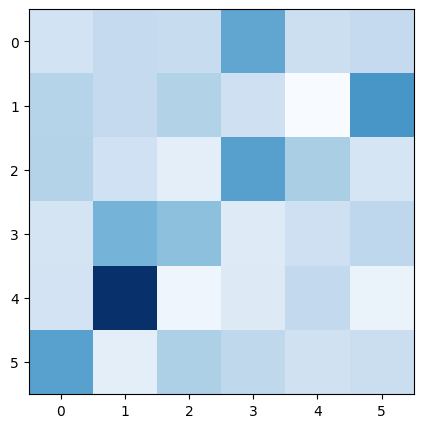

In [ ]:
plt.figure(figsize = (6,5))
plt.imshow(weight[0].detach().numpy(), cmap='Blues')
plt.show()

In [ ]:
words = ["the", "cat", "sat", "on", "the", "mat"]

In [ ]:
vocab = {w:i for i, w in enumerate(sorted(set(words)))}
vocab

{'cat': 0, 'mat': 1, 'on': 2, 'sat': 3, 'the': 4}

In [ ]:
embed = nn.Embedding(len(vocab), 64)
ids = torch.tensor([vocab[w] for w in words]).unsqueeze(0)
ids.shape

torch.Size([1, 6])

In [ ]:
x = embed(ids)
x.shape

torch.Size([1, 6, 64])

In [ ]:
out, weight = sa(x)
out.shape, weight.shape

(torch.Size([1, 6, 64]), torch.Size([1, 6, 6]))

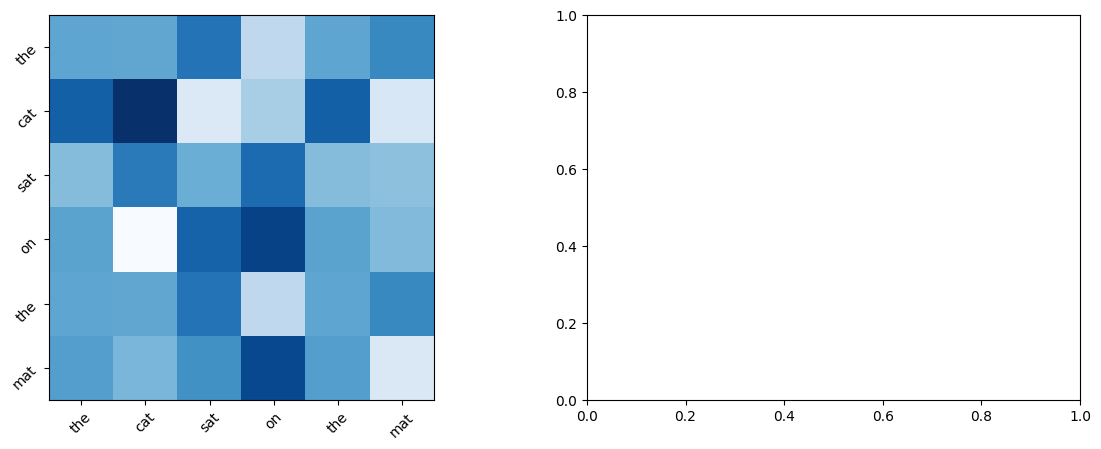

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
im = axes[0].imshow(weight[0].detach().numpy(), cmap='Blues')
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(words, rotation=45)
axes[0].set_yticks(range(6))
axes[0].set_yticklabels(words, rotation=45)
plt.show()

In [ ]:
words

['the', 'cat', 'sat', 'on', 'the', 'mat']

In [ ]:
seq_len = len(words)
seq_len

6

In [ ]:
d_model = 16
embed = nn.Embedding(seq_len, d_model)

In [ ]:
ids = torch.arange(seq_len).unsqueeze(0)
ids.shape

torch.Size([1, 6])

In [ ]:
X = embed(ids)
X.shape

torch.Size([1, 6, 16])

In [ ]:
[1, 6, 16] -> (1, 16, 6) -> (1, 2, 8, 6) -> (1, 1, 1, 1, 2, 2, 4, 2, 3)

In [ ]:
# (1, seq_len, self.d_model) -> (1, -1, seq_len, self.d_k)

# d_model = 16
# num_head = 8
# d_k = d_model // num_head = 16 // 8 = 2
# (1, 6, 16) -> (1, 8, 6, 2)

# (1, 6, 16) -> (1, 8, 6, 2) -> 8 x (1, 6, 2)

In [ ]:
W_q = nn.Linear(d_model, d_model)
W_k = nn.Linear(d_model, d_model)
W_v = nn.Linear(d_model, d_model)

Q = W_q(X)
K = W_k(X)
V = W_v(X)

Q.shape, K.shape, V.shape


(torch.Size([1, 6, 16]), torch.Size([1, 6, 16]), torch.Size([1, 6, 16]))

In [ ]:
scores = torch.matmul(Q, K.transpose(-2, -1))
scores.shape

torch.Size([1, 6, 6])

In [ ]:
dict(zip(words, scores[0,0].detach().numpy().round(2)))

{'the': -0.12, 'cat': -0.71, 'sat': -1.53, 'on': 1.06, 'mat': -0.82}

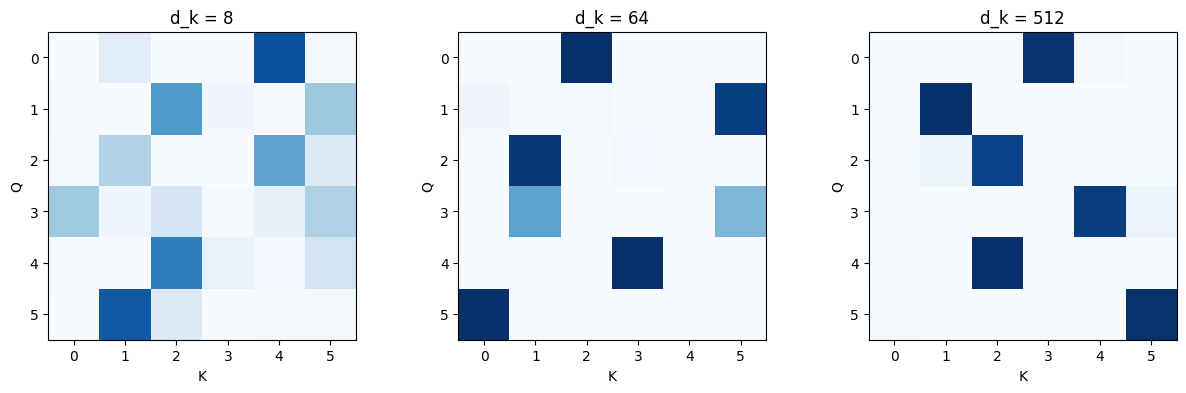

In [ ]:
dims = [8, 64, 512]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, d_k in enumerate(dims):
    q = torch.randn(1, 6, d_k)
    k = torch.randn(1, 6, d_k)

    raw_scores = torch.matmul(q, k.transpose(-2, -1))
    attn = F.softmax(raw_scores, dim=-1)

    axes[idx].imshow(attn[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    axes[idx].set_title(f'd_k = {d_k}')
    axes[idx].set_xlabel('K')
    axes[idx].set_ylabel('Q')


plt.show()

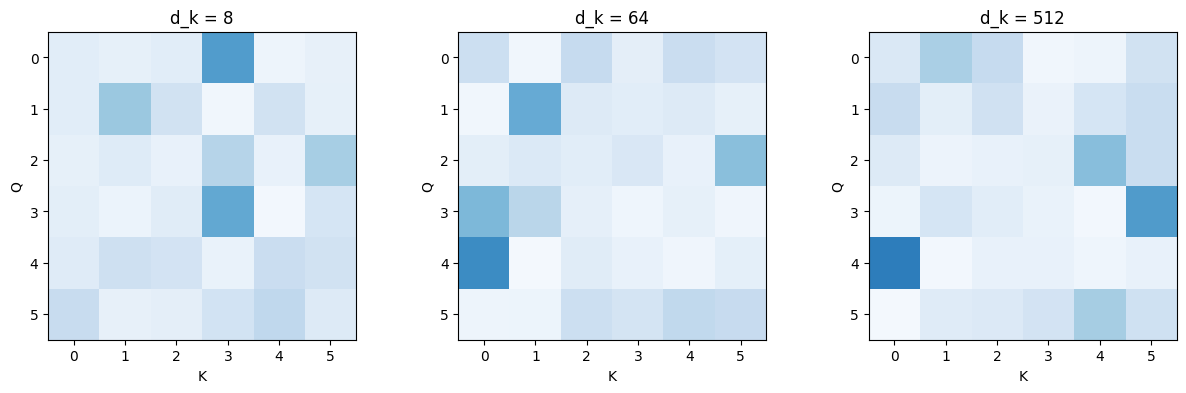

In [ ]:
dims = [8, 64, 512]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, d_k in enumerate(dims):
    q = torch.randn(1, 6, d_k)
    k = torch.randn(1, 6, d_k)

    raw_scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    attn = F.softmax(raw_scores, dim=-1)

    axes[idx].imshow(attn[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    axes[idx].set_title(f'd_k = {d_k}')
    axes[idx].set_xlabel('K')
    axes[idx].set_ylabel('Q')


plt.show()

In [ ]:
def scaled_dot_product_attention(Q, K, V):
    d_k = K.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    attn_weight = F.softmax(scores, dim=-1)
    output = torch.matmul(attn_weight, V)
    return output, attn_weights

In [ ]:
# (1, seq_len, self.d_model) -> (1, -1, seq_len, self.d_k)

# d_model = 16
# num_head = 8
# d_k = d_model // num_head = 16 // 8 = 2
# (1, 6, 16) -> (1, 8, 6, 2)

# (1, 6, 16) -> (1, 8, 6, 2) -> 8 x (1, 6, 2)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.d_model = d_model      # 512
        self.num_heads = num_heads  # 8

        # 512 // 8 : 64
        self.d_k = self.d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x, batch_size):
        x = x.view(batch_size, -1, self.num_heads, self.d_k)  # (1, 6, 8, 2)
        return x.transpose(1, 2)   # (1, 8, 6, 2)

    def forward(self, q, k, v, mask = None):
        batch_size = q.size(0)  # (1, 6, 16)

        Q = self.W_q(q)
        K = self.W_k(k)
        V = self.W_v(v)

        Q = self.split_heads(Q, batch_size)
        K = self.split_heads(K, batch_size)
        V = self.split_heads(V, batch_size)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask==0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)
        output = torch.matmul(attn_weights, V)   # (batch, num_heads, seq_len, d_k)

        output = output.transpose(1,2).contiguous() # (batch, seq_len, num_heads, d_k) : (1, 6, 8, 2)
        output = output.view(batch_size, -1, self.d_model)  # (1, ?, 16) : (1, 6, 16)

        output = self.W_o(output)

        return output, attn_weights


In [ ]:
mha = MultiHeadAttention(d_model = 128, num_heads = 8) # -> 128 // 8 = 16
x = torch.randn(2, 10, 128)

output, weights = mha(x, x, x)

In [ ]:
output.shape, weights.shape

(torch.Size([2, 10, 128]), torch.Size([2, 8, 10, 10]))

In [ ]:
words = ["the", "cat", "sat", "on", "the", "mat"]
# 8개의 attn weight 시각화

embed = nn.Embedding(6, 128)
ids = torch.tensor([[0, 1, 2, 3, 4, 5]])
x = embed(ids)
x.shape

torch.Size([1, 6, 128])

In [ ]:
mha = MultiHeadAttention(d_model = 128, num_heads = 8) # -> 128 // 8 = 16
out, weights = mha(x, x, x)

out.shape, weights.shape

(torch.Size([1, 6, 128]), torch.Size([1, 8, 6, 6]))

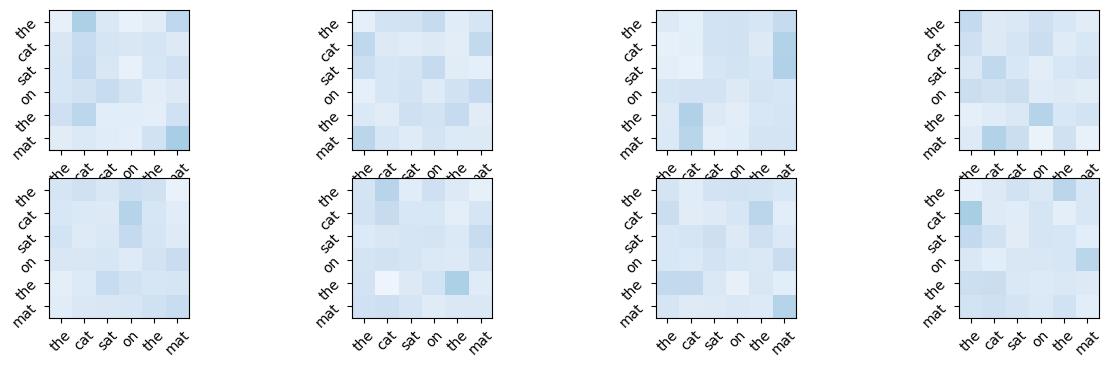

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(15, 4))
for h in range(8):

    ax = axes[h // 4, h %4]
    im = ax.imshow(weights[0, h].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(6))
    ax.set_xticklabels(words, rotation=45)
    ax.set_yticks(range(6))
    ax.set_yticklabels(words, rotation=45)

plt.show()

In [ ]:
single_head = MultiHeadAttention(d_model = 128, num_heads = 1)
single_params = sum(p.numel() for p in single_head.parameters())

multi_head = MultiHeadAttention(d_model = 128, num_heads = 8)
multi_params = sum(p.numel() for p in multi_head.parameters())

In [ ]:
single_params, multi_params

(66048, 66048)

In [ ]:
def scaled_dot_product_attention(Q, K, V, mask = None):
    d_k = K.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask==0, -1e9)

    attn_weight = F.softmax(scores, dim=-1)
    output = torch.matmul(attn_weight, V)
    return output, attn_weight

In [ ]:
scores_example = torch.tensor([[2.0, 1.0, 0.5]])
no_mask = F.softmax(scores_example, dim=-1)

In [ ]:
no_mask

tensor([[0.6285, 0.2312, 0.1402]])

In [ ]:
scores_zero = scores_example.clone()
scores_zero[0,2] = 0
scores_zero

tensor([[2., 1., 0.]])

In [ ]:
mask_zero = F.softmax(scores_zero, dim=-1)
mask_zero

tensor([[0.6652, 0.2447, 0.0900]])

In [ ]:
scores_new = scores_example.clone()
scores_new[0,2] = -1e9 # 0.000000001
scores_new

tensor([[ 2.0000e+00,  1.0000e+00, -1.0000e+09]])

In [ ]:
mask_zero = F.softmax(scores_new, dim=-1)
mask_zero

tensor([[0.7311, 0.2689, 0.0000]])

In [ ]:
words

['the', 'cat', 'sat', 'on', 'the', 'mat']

In [ ]:
seq_len = len(words)
seq_len

6

In [ ]:
mask = torch.tril(torch.ones(seq_len, seq_len)).unsqueeze(0)
mask

tensor([[[1., 0., 0., 0., 0., 0.],
         [1., 1., 0., 0., 0., 0.],
         [1., 1., 1., 0., 0., 0.],
         [1., 1., 1., 1., 0., 0.],
         [1., 1., 1., 1., 1., 0.],
         [1., 1., 1., 1., 1., 1.]]])

In [ ]:
mask.shape

torch.Size([1, 6, 6])

In [ ]:
d_k = 64
Q = torch.randn(1, seq_len, d_k)
K = torch.randn(1, seq_len, d_k)
V = torch.randn(1, seq_len, d_k)

In [ ]:
_, weight_no_mask = scaled_dot_product_attention(Q, K, V)
_, weight_mask = scaled_dot_product_attention(Q, K, V, mask=mask)

In [ ]:
weight_no_mask.shape, weight_mask.shape

(torch.Size([1, 6, 6]), torch.Size([1, 6, 6]))

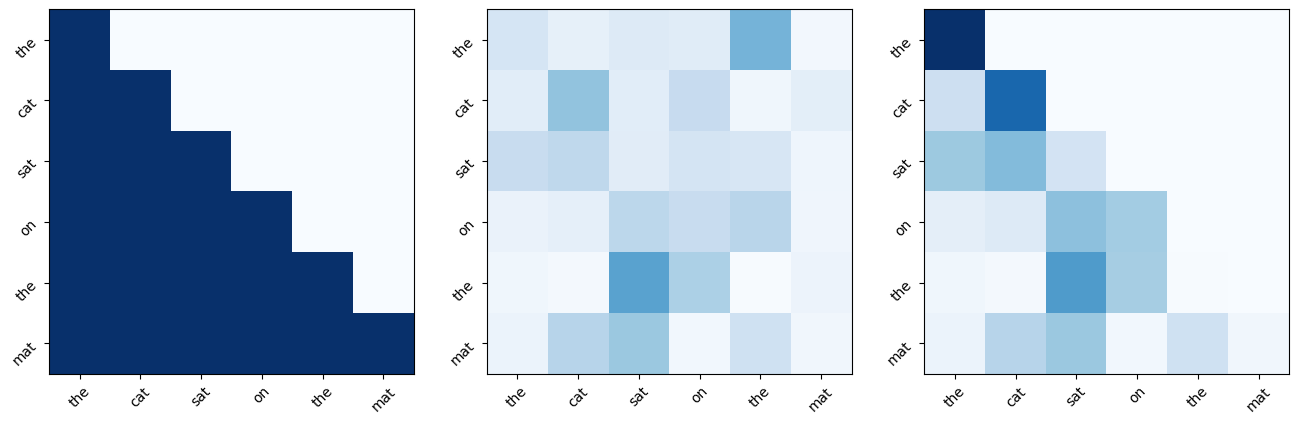

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(mask[0].numpy(), cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels(words, rotation=45)
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(words, rotation=45)

axes[1].imshow(weight_no_mask[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks(range(seq_len))
axes[1].set_xticklabels(words, rotation=45)
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels(words, rotation=45)

axes[2].imshow(weight_mask[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[2].set_xticks(range(seq_len))
axes[2].set_xticklabels(words, rotation=45)
axes[2].set_yticks(range(seq_len))
axes[2].set_yticklabels(words, rotation=45)

plt.show()

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

In [ ]:
# I love you
# You love I

# seq2seq : RNN, LSTM, GRU  -> sequential 관계
# transformer : attention   -> 병렬적으로 연산 ,

# -> postion encoding

In [ ]:
# i go to .......600......                 school
# 0 1   2                                     600

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.d_k = embed_dim
        self.W_q = nn.Linear(embed_dim, embed_dim)
        self.W_k = nn.Linear(embed_dim, embed_dim)
        self.W_v = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)


        scores = torch.bmm(Q, K.transpose(1,2))
        scores = scores / math.sqrt(self.d_k)

        attn_weights = F.softmax(scores, dim=-1)
        output = torch.bmm(attn_weights, V)

        return output, attn_weights

In [ ]:
model = SelfAttention(embed_dim=128)
x1 = torch.randn(1, 5, 128)
out1, w1 = model(x1)

In [ ]:
perm = [2, 0, 4, 1, 3]
x2 = x1[:, perm, :]   # pos0, pos1, pos2, pos3, pos4 -> pos2, pos0, pos4, pos1, pos3
out2, w2 = model(x2)

In [ ]:
inv_perm = [perm.index(i) for i in range(5)]
out2_restored = out2[:, inv_perm, :]

diff = (out1 - out2_restored).abs().max().item()
diff

1.7881393432617188e-07

In [ ]:
0.00000017881393432617188

1.7881393432617188e-07

In [ ]:
# x -> embedding(x) -> embedding + [0, 1, 2, ,,,, n]

In [ ]:
embed_dim = 128
x = torch.randn(1, 500, embed_dim)

In [ ]:
batch, seq_len, d = x.shape
positions = torch.arange(seq_len).float()

positions = positions.unsqueeze(0).unsqueeze(-1)
positions = positions.expand(batch, seq_len, d)

positioned_x = x + positions

In [ ]:
x

tensor([[[ 0.7419, -1.0426, -1.5818,  ..., -0.1088,  1.0711, -2.6631],
         [-0.6188, -0.7414, -0.1209,  ...,  1.1959,  0.4818, -1.7237],
         [ 0.3328,  0.3821,  1.3228,  ...,  1.3434, -0.2359, -0.3285],
         ...,
         [ 0.1326, -0.1887,  0.1365,  ...,  0.4828,  2.8981,  0.4573],
         [-1.2780,  2.5804,  0.5344,  ...,  1.5504,  0.3450,  1.1436],
         [-1.5049,  1.7958,  0.0858,  ..., -1.7845,  0.4639,  0.2189]]])

In [ ]:
x.min(), x.max()

(tensor(-2.4319), tensor(501.5268))

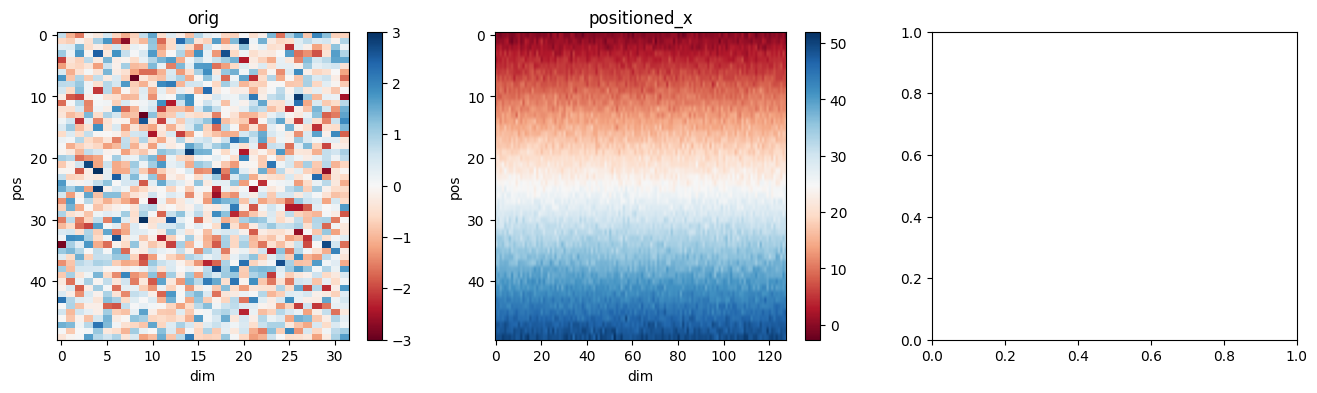

In [ ]:
# 501.5268 -> 위치정보 : 500, embed_정보 : 1.5268
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(x[0, :50, :32].numpy(), cmap='RdBu', aspect='auto', vmin=-3, vmax = 3)
axes[0].set_title('orig')
axes[0].set_xlabel('dim')
axes[0].set_ylabel('pos')
plt.colorbar(im0, ax=axes[0])


im1 = axes[1].imshow(positioned_x[0, :50, :].numpy(), cmap='RdBu', aspect='auto')
axes[1].set_title('positioned_x')
axes[1].set_xlabel('dim')
axes[1].set_ylabel('pos')
plt.colorbar(im1, ax=axes[1])

plt.show()

In [ ]:
# 0 ~ 500 -> 0~ 1

# 0, 1, 2, 3, 4, 5,,,
# 0, 1/500, 2/500, ,,,

In [ ]:
# seq_len : 50
# seq_len : 500

# x1 + 1/50, x2 + 2/50 ,,,,,
# x1 + 1/500, x2 + 2/500

In [ ]:
# x1 + 0.01
# x2 + 0.02
# x3 + 0.003
# ..

In [ ]:
x.shape

torch.Size([1, 500, 128])

In [ ]:
# 위치0 : [1, 0, 0, 0, 0,,,,]
# 위치1 : [0, 1, 0, 0, 0,,,,]

# ...

# 위치n : [0,0,0,0,0, 1,0 ,..]

In [ ]:
def add_one_hot_position(x):
    batch, seq_len, d = x.shape
    position = torch.eye(d)[:seq_len]
    position = position.unsqueeze(0).expand(batch, -1, -1)
    return x + position

In [ ]:
torch.eye(d)[:seq_len]

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [ ]:
# (1, 0) * (0, 1) -> 0

In [ ]:
d = 128
onehot = torch.eye(d)
F.cosine_similarity(onehot[0:1], onehot[1:2]).item(),  F.cosine_similarity(onehot[1:2], onehot[2:3]).item(), F.cosine_similarity(onehot[0:1], onehot[50:51]).item()

(0.0, 0.0, 0.0)

In [ ]:
onehot = torch.eye(d)
onehot[0:1]

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.]])

In [ ]:
onehot[1:2]

tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.]])

In [ ]:
# nn.Embedding() (x) -> embed_x

In [ ]:
max_len = 512
embed_dim = 128
pos_embedding = nn.Embedding(max_len, embed_dim)

x = torch.randn(1, 10, embed_dim)
position = torch.arange(10).unsqueeze(0)
x_with_pos = x + pos_embedding(position)

In [ ]:
x_with_pos

tensor([[[-0.7189, -1.7979,  1.8632,  ..., -1.7277, -2.0653, -2.7463],
         [ 0.8391,  1.0603,  2.5208,  ...,  4.5430,  1.1331, -0.0753],
         [ 2.2518,  1.1100,  1.7264,  ..., -1.2289,  0.3133,  1.6353],
         ...,
         [-2.4183,  0.5661,  0.8553,  ..., -0.4209, -0.4300, -0.1156],
         [-0.7080,  0.0784, -0.9355,  ..., -0.3306, -2.1506,  1.6137],
         [ 1.5333,  0.7456,  0.4737,  ...,  2.8020,  1.7536,  0.3506]]],
       grad_fn=<AddBackward0>)

In [ ]:
512 * 128

65536

In [ ]:
# 위치정보가 너무 커서 원래 임베딩 값을 가리면 안된다
# 위치 고유성을 가져야하고 (3번 포지션은 같은값)
# 길이에 영향을 받지 않으면서
# 인접 유사성이 없어야

In [ ]:
# sinusoidal positional encoding

In [ ]:
# sin(x) -> 360도 (2파이)
# sin(x/2) -> 720도 (4파이)
# sin(2x) -> 180도 (pi)

# 낮은 차원 -> 주기가 빨라진다 -> 가까운 위치를 구분
# 높은 차원 -> 주기가 느려진다 -> 먼 위치 구분

In [ ]:
# 상대적인 위치 표현 O
# sin(a + b) = sin(a) * cos(b) + cos(a) * sin(b)

# sin, cos : -1 ~ 1

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len = 5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()   # (max_len, 1)

        # div_term = 10000 ^ (2i / d_model)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [ ]:
pe = PositionalEncoding(d_model=128)
x = torch.randn(1, 10, 128)
out = pe(x)

In [ ]:
x.shape, out.shape, pe.pe.shape

(torch.Size([1, 10, 128]),
 torch.Size([1, 10, 128]),
 torch.Size([1, 5000, 128]))

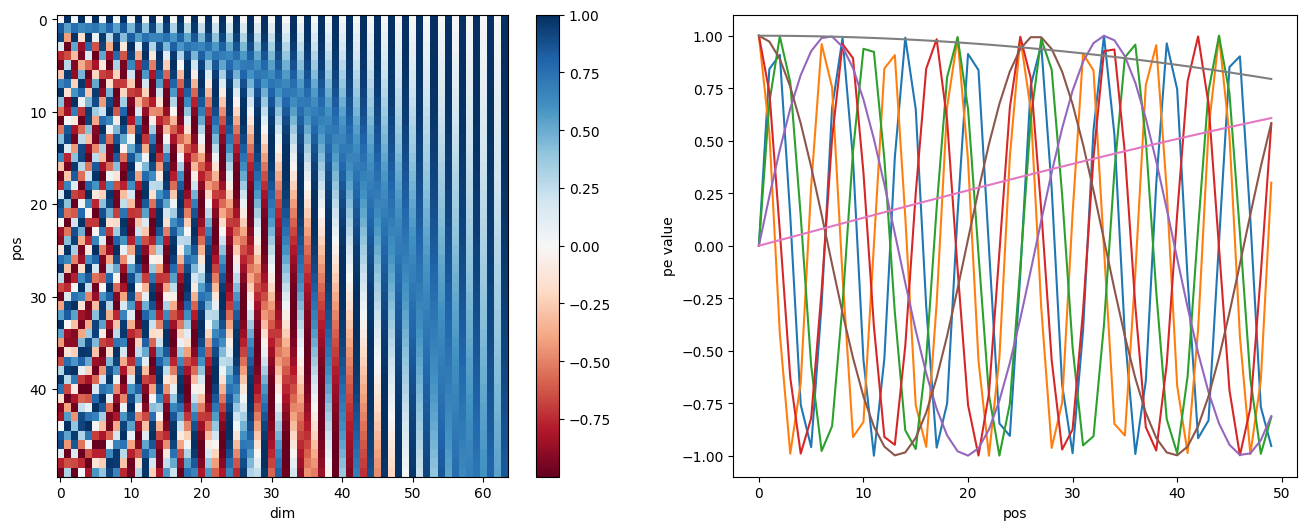

In [ ]:
pe_vis = PositionalEncoding(d_model=128, max_len=100)
pe_matrix = pe_vis.pe[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im = axes[0].imshow(pe_matrix[:50, :64], cmap='RdBu', aspect='auto')
axes[0].set_xlabel('dim')
axes[0].set_ylabel('pos')
plt.colorbar(im, ax=axes[0])

for dim in [0, 1, 4, 5, 20, 21, 60, 61]:
    axes[1].plot(pe_matrix[:50, dim], label=f'dim {dim}')
axes[1].set_xlabel('pos')
axes[1].set_ylabel('pe value')

plt.show()

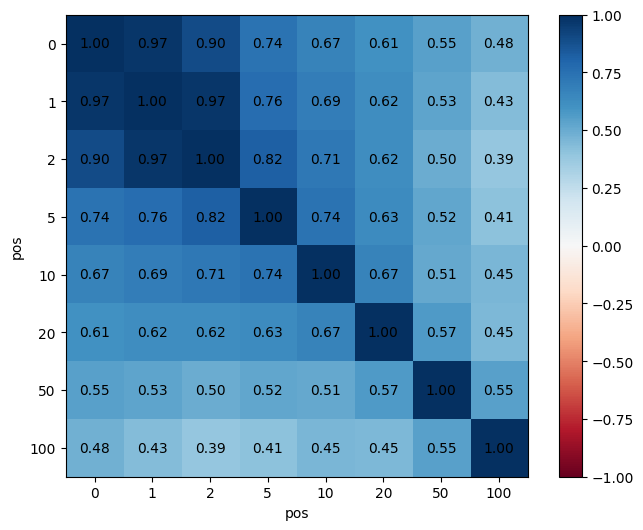

In [ ]:
pe_128 = PositionalEncoding(d_model=128, max_len=200)
pe_mat = pe_128.pe[0].numpy()

positions = [0, 1, 2,5, 10, 20, 50, 100]
pos_vecs = pe_mat[positions]

similarity = np.zeros((len(positions), len(positions)))
for i in range(len(positions)):
    for j in range(len(positions)):
        cos_sim = np.dot(pos_vecs[i], pos_vecs[j]) / (np.linalg.norm(pos_vecs[i]) * np.linalg.norm(pos_vecs[j]))
        similarity[i, j] = cos_sim

plt.figure(figsize=(8,6))
plt.imshow(similarity, cmap='RdBu', vmin=-1, vmax=1)

plt.xticks(range(len(positions)), positions)
plt.yticks(range(len(positions)), positions)
plt.xlabel('pos')
plt.ylabel('pos')
plt.colorbar()
for i in range(len(positions)):
    for j in range(len(positions)):
        plt.text(j, i, f'{similarity[i,j]:.2f}', ha='center', va='center')

plt.show()

In [ ]:
pos_vecs[i].shape

(10, 128)

In [ ]:
np.dot(pos_vecs[i], pos_vecs[i].transpose(-1, -2)).shape

(10, 10)

In [ ]:
pe_mat[positions].shape

(8, 128)

In [ ]:
similarity

array([[64.        , 62.09368515, 57.38185883, 47.18501282, 42.82002258,
        38.93404388, 34.95500565, 30.5434494 ],
       [62.09368515, 64.        , 62.09368515, 48.58603287, 44.10345459,
        39.52834702, 33.73007202, 27.69049072],
       [57.38185883, 62.09368515, 64.        , 52.18622971, 45.72051239,
        39.6205368 , 31.71107101, 24.92125702],
       [47.18501282, 48.58603287, 52.18622971, 64.        , 47.18501282,
        40.48331833, 33.07542419, 26.35830879],
       [42.82002258, 44.10345459, 45.72051239, 47.18501282, 64.        ,
        42.82002258, 32.57882309, 29.11000824],
       [38.93404388, 39.52834702, 39.6205368 , 40.48331833, 42.82002258,
        64.        , 36.24380493, 28.90799332],
       [34.95500565, 33.73007202, 31.71107101, 33.07542419, 32.57882309,
        36.24380493, 64.        , 34.95500946],
       [30.5434494 , 27.69049072, 24.92125702, 26.35830879, 29.11000824,
        28.90799332, 34.95500946, 64.        ]])